# 02 Testing Purifying Selection hypothesis

Here we are introducing new AF metrices that we added 


## Variant Count Metrics

### **n_variants**
- **Type:** Integer
- **Description:** Total number of unique variants in this gene
- **Calculation:** Count of unique variant_id after deduplication by highest absolute effect

### **n_variants_common**
- **Type:** Integer
- **Description:** Number of common variants (AF ≥ 0.05)
- **Calculation:** Count where AF ≥ 0.05

### **n_variants_rare**
- **Type:** Integer
- **Description:** Number of rare variants (AF < 0.05)
- **Calculation:** Count where AF < 0.05

### **n_variants_common_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF ≥ 0.05
- **Calculation:** Count where perm_AF ≥ 0.05
- **Note:** Only present when permuted AFs are available

### **n_variants_rare_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF < 0.05
- **Calculation:** Count where perm_AF < 0.05
- **Note:** Only present when permuted AFs are available

### **variants_per_kb**
- **Type:** Float
- **Description:** Variant density normalized by genomic length
- **Calculation:** n_variants / (genomic_length / 1000)

## Genetic Variance (Vg) Metrics

### **vg_predicted**
- **Type:** Float
- **Description:** Total predicted genetic variance for this gene
- **Formula:** Σ[2 × AF × (1 - AF) × β²] across all variants
- **Note:** Primary Vg metric using observed allele frequencies

### **vg_predicted_perm**
- **Type:** Float
- **Description:** Total predicted genetic variance using permuted allele frequencies
- **Formula:** Σ[2 × perm_AF × (1 - perm_AF) × β²]
- **Note:** Used as null expectation for selection analyses

### **vg_common**
- **Type:** Float
- **Description:** Genetic variance contribution from common variants (AF ≥ 0.05)
- **Calculation:** Sum of vg_contribution where AF ≥ 0.05

### **vg_rare**
- **Type:** Float
- **Description:** Genetic variance contribution from rare variants (AF < 0.05)
- **Calculation:** Sum of vg_contribution where AF < 0.05

### **vg_common_perm**
- **Type:** Float
- **Description:** Genetic variance from common variants using permuted AFs
- **Note:** Only present when permuted AFs are available

### **vg_rare_perm**
- **Type:** Float
- **Description:** Genetic variance from rare variants using permuted AFs
- **Note:** Only present when permuted AFs are available


In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [6]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '02_af_filter'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [7]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [17]:
print('df_real columns:', sorted(df_real.columns))
print('df_synth columns:', sorted(df_synth.columns))

candidate_cols = [
    c for c in df_real.columns
    if any(k in c.lower() for k in ['af', 'vg', 'promoter', 'upstream', 'downstream', 'tss', 'region'])
]
print('\nCandidate columns in df_real:')
for c in sorted(candidate_cols):
    print(' ', c)

for col in ['vg_predicted', 'vg_common', 'vg_rare', 'n_variants_common', 'n_variants_rare']:
    if col in df_real.columns:
        print(f"\n{col} summary:")
        print(
            df_real.select(
                pl.col(col).drop_nans().drop_nulls().alias(col)
            ).to_pandas()[col].describe(percentiles=[0.25, 0.5, 0.75])
        )

df_real columns: ['Episcore', 'N85', 'N90', 'RVIS_score', 'af_gradient', 'chrom', 'coding_length', 'cv_effect_N90', 'depletion_common', 'depletion_distal_upstream', 'depletion_down_distal', 'depletion_down_proximal', 'depletion_high_impact', 'depletion_promoter_core', 'depletion_proximal_upstream', 'depletion_rare', 'enrich_vg_distal_upstream', 'enrich_vg_down_distal', 'enrich_vg_down_proximal', 'enrich_vg_promoter_core', 'enrich_vg_proximal_upstream', 'entropy_distal_upstream', 'entropy_down_distal', 'entropy_down_proximal', 'entropy_effect', 'entropy_promoter_core', 'entropy_proximal_upstream', 'exonic_length', 'frac_high_impact_05', 'frac_high_impact_10', 'gene_id', 'gene_symbol', 'gene_type', 'genomic_length', 'intronic_length', 'is_mane', 'loeuf_score', 'mane_transcript_id', 'max_abs_effect', 'max_dist_to_tss', 'max_variant_id', 'max_variant_score', 'mean_abs_distal_upstream', 'mean_abs_down_distal', 'mean_abs_down_proximal', 'mean_abs_effect', 'mean_abs_promoter_core', 'mean_abs_

In [9]:
NOTEBOOK_NAME = '02_af_filter'

SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']
PLOT_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'clingen_null': 'ClinGen_HI_Synth',
    'background': 'Background_Gnomad',
    'background_null': 'Background_Synth',
}

palette = {
    'background': SOURCE_PALETTE['background'],
    'background_null': SOURCE_PALETTE['background_null'],
    'clingen': SOURCE_PALETTE['clingen'],
    'clingen_null': SOURCE_PALETTE['clingen_null'],
}

required_cols = [
    'source', 'gene_symbol',
    'vg_predicted', 'vg_predicted_perm',
    'vg_common', 'vg_common_perm',
    'vg_rare', 'vg_rare_perm',
    'n_variants_common', 'n_variants_rare', 'variants_per_kb',
    'loeuf_score',
]

all_genes = pl.concat([df_real, df_synth], how='diagonal_relaxed')
missing_cols = [c for c in required_cols if c not in all_genes.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

is_synth = pl.col('source').str.contains('null')

plot_df = (
    all_genes
    .select(required_cols)
    .with_columns([
        pl.when(is_synth).then(pl.col('vg_predicted_perm')).otherwise(pl.col('vg_predicted')).alias('vg_total_for_plot'),
        pl.when(is_synth).then(pl.col('vg_common_perm')).otherwise(pl.col('vg_common')).alias('vg_common_for_plot'),
        pl.when(is_synth).then(pl.col('vg_rare_perm')).otherwise(pl.col('vg_rare')).alias('vg_rare_for_plot'),
    ])
    .with_columns([
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_rare_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_rare_fraction'),
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_common_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_common_fraction'),
    ])
    .filter(pl.col('source').is_in(SOURCE_ORDER))
    .drop_nulls(subset=['source', 'vg_total_for_plot'])
    .to_pandas()
)

plot_df['source_label'] = plot_df['source'].map(PLOT_LABELS)
source_label_order = [PLOT_LABELS[s] for s in SOURCE_ORDER]
palette_by_label = {PLOT_LABELS[s]: palette[s] for s in SOURCE_ORDER}

print('Phase 2 config and shared data prepared.')

Phase 2 config and shared data prepared.


# Phase 2 — The Filter (AF Analysis)

Is this variance driven by common variation or rare, potentially deleterious mutations?

[save_plot] Saved: figuree_AF_Filter_Selection_Shift_GnomAD_vs_SynthPerm_ByCohort_20022026_1223.pdf
[save_plot] Saved: figuree_AF_Filter_Selection_Shift_GnomAD_vs_SynthPerm_ByCohort_20022026_1223.svg


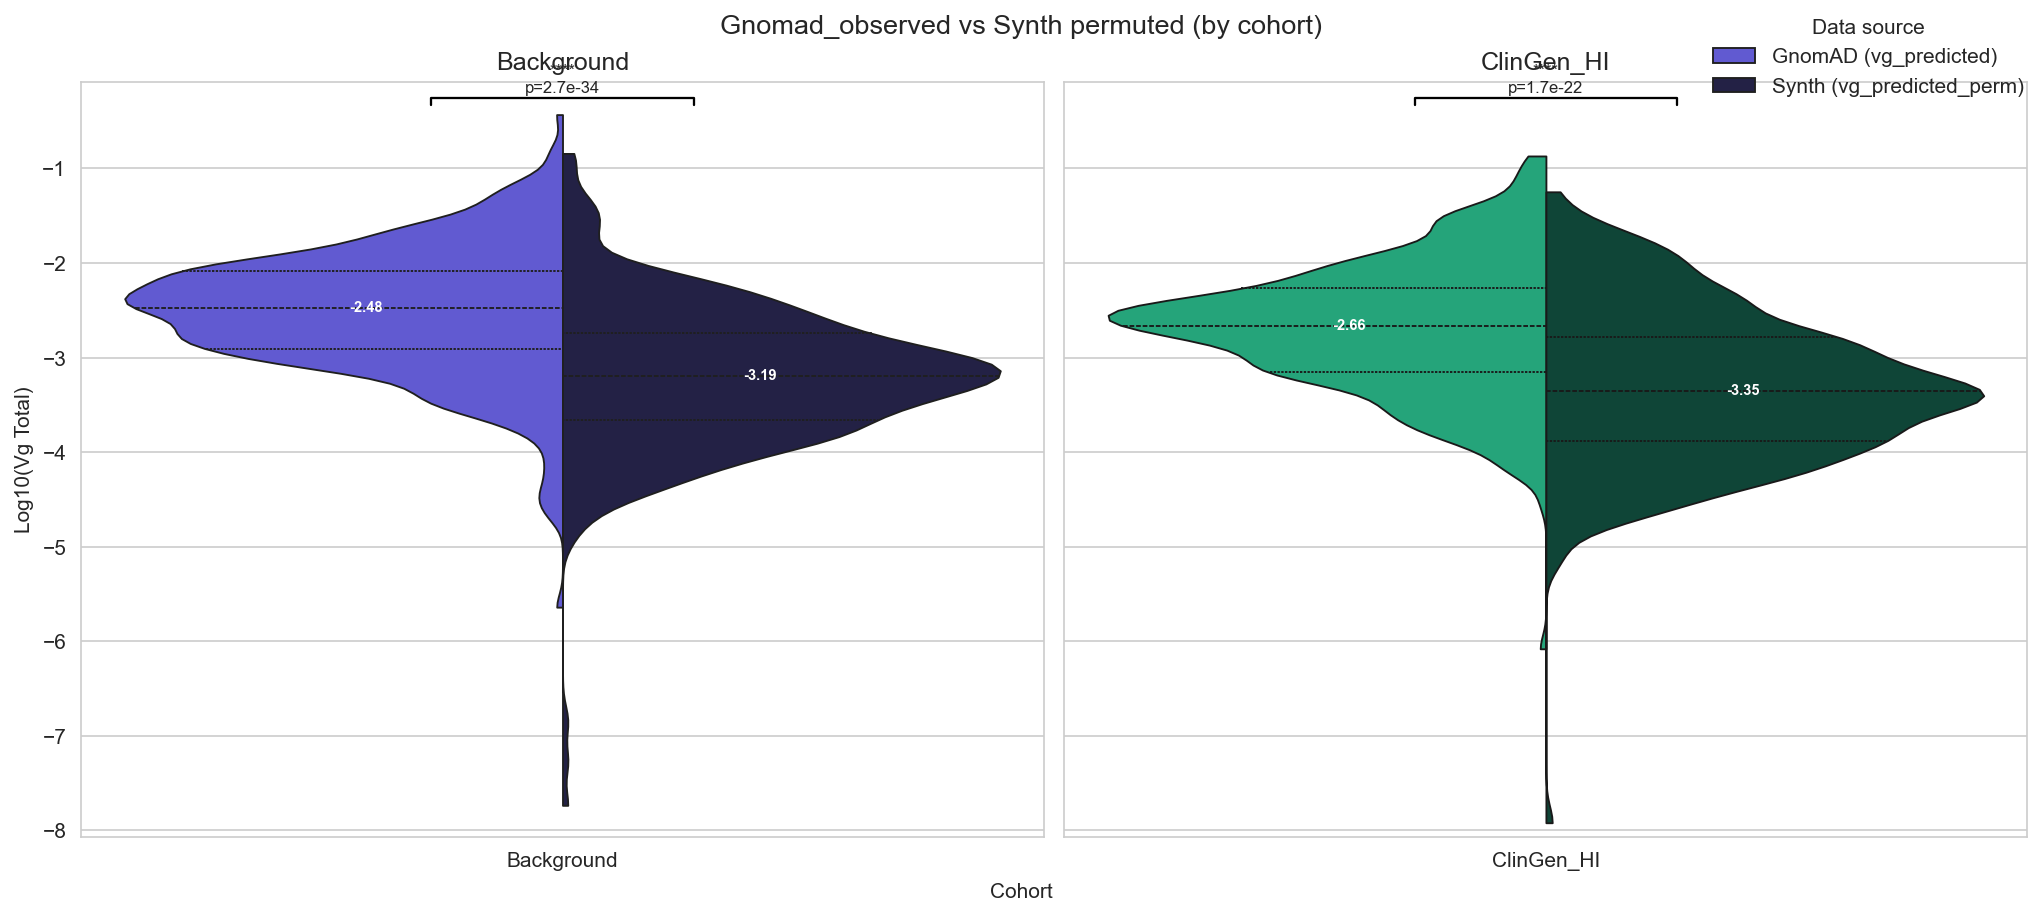

In [10]:
selection_df = all_genes.select(['source', 'vg_predicted', 'vg_predicted_perm']).to_pandas()
selection_df = selection_df[selection_df['source'].isin(SOURCE_ORDER)].copy()

selection_df['cohort'] = np.where(
    selection_df['source'].str.contains('background'),
    'Background',
    'ClinGen_HI',
)
selection_df['dataset_type'] = np.where(
    selection_df['source'].str.contains('null'),
    'Synth (vg_predicted_perm)',
    'GnomAD (vg_predicted)',
)
selection_df['vg_total_for_plot'] = np.where(
    selection_df['source'].str.contains('null'),
    selection_df['vg_predicted_perm'],
    selection_df['vg_predicted'],
)
selection_df = selection_df[selection_df['vg_total_for_plot'] > 0].copy()
selection_df['log10_vg_total'] = np.log10(selection_df['vg_total_for_plot'])
selection_df['panel'] = selection_df['cohort']

def _p_to_stars(p_value):
    if p_value < 1e-4:
        return '****'
    if p_value < 1e-3:
        return '***'
    if p_value < 1e-2:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'

with autosave('AF_Filter_Selection_Shift_GnomAD_vs_SynthPerm_ByCohort'):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), sharey=True, constrained_layout=True)

    panel_order = ['Background', 'ClinGen_HI']
    hue_order = ['GnomAD (vg_predicted)', 'Synth (vg_predicted_perm)']

    global_y_min = selection_df['log10_vg_total'].min()
    global_y_max = selection_df['log10_vg_total'].max()

    for ax, panel in zip(axes, panel_order):
        sub = selection_df[selection_df['panel'] == panel].copy()

        panel_palette = {
            'GnomAD (vg_predicted)': SOURCE_PALETTE['background'] if panel == 'Background' else SOURCE_PALETTE['clingen'],
            'Synth (vg_predicted_perm)': SOURCE_PALETTE['background_null'] if panel == 'Background' else SOURCE_PALETTE['clingen_null'],
        }

        sns.violinplot(
            data=sub,
            x='panel',
            y='log10_vg_total',
            hue='dataset_type',
            order=[panel],
            hue_order=hue_order,
            split=True,
            dodge=True,
            inner='quart',
            cut=0,
            bw_adjust=0.65,
            linewidth=0.9,
            palette=panel_palette,
            ax=ax,
        )

        gnomad_vals = sub[sub['dataset_type'] == 'GnomAD (vg_predicted)']['log10_vg_total'].dropna()
        synth_vals = sub[sub['dataset_type'] == 'Synth (vg_predicted_perm)']['log10_vg_total'].dropna()

        # Add white median annotations
        if len(gnomad_vals) > 0:
            gnomad_median = gnomad_vals.median()
            ax.text(-0.18, gnomad_median, f'{gnomad_median:.2f}', 
                   ha='center', va='center', fontsize=7, color='white', weight='bold')
        
        if len(synth_vals) > 0:
            synth_median = synth_vals.median()
            ax.text(0.18, synth_median, f'{synth_median:.2f}', 
                   ha='center', va='center', fontsize=7, color='white', weight='bold')

        y_top = global_y_max + 0.18
        if len(gnomad_vals) >= 3 and len(synth_vals) >= 3:
            _, p_val = stats.mannwhitneyu(gnomad_vals, synth_vals, alternative='two-sided')
            x1, x2 = -0.12, 0.12
            bracket_h = 0.08
            ax.plot([x1, x1, x2, x2], [y_top - bracket_h, y_top, y_top, y_top - bracket_h], lw=1.1, c='black')
            ax.text(0, y_top + 0.02, f"{_p_to_stars(p_val)}\np={p_val:.1e}", ha='center', va='bottom', fontsize=8)

        ax.set_ylim(global_y_min - 0.15, global_y_max + 0.35)
        ax.set_title(panel, fontsize=12)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)

        legend_ = ax.get_legend()
        if legend_ is not None:
            legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles[:2], labels[:2], title='Data source', frameon=False, loc='upper right')

    axes[0].set_ylabel('Log10(Vg Total)', fontsize=10)
    axes[1].set_ylabel('')
    fig.supxlabel('Cohort', fontsize=10)
    fig.suptitle('Gnomad_observed vs Synth permuted (by cohort)', fontsize=13)

ClinGen haploinsufficient genes display a significant depletion in genetic variancecompared to null expectations (p<10−21), evidencing strong purifying selection that is notably absent in the background gene set.

# Rare/Common ratio vs constraint (LOEUF deciles)

[save_plot] Saved: figuree_AF_Filter_CommonFraction_vs_LOEUF_Deciles_withTrend_20022026_1223.pdf
[save_plot] Saved: figuree_AF_Filter_CommonFraction_vs_LOEUF_Deciles_withTrend_20022026_1223.svg


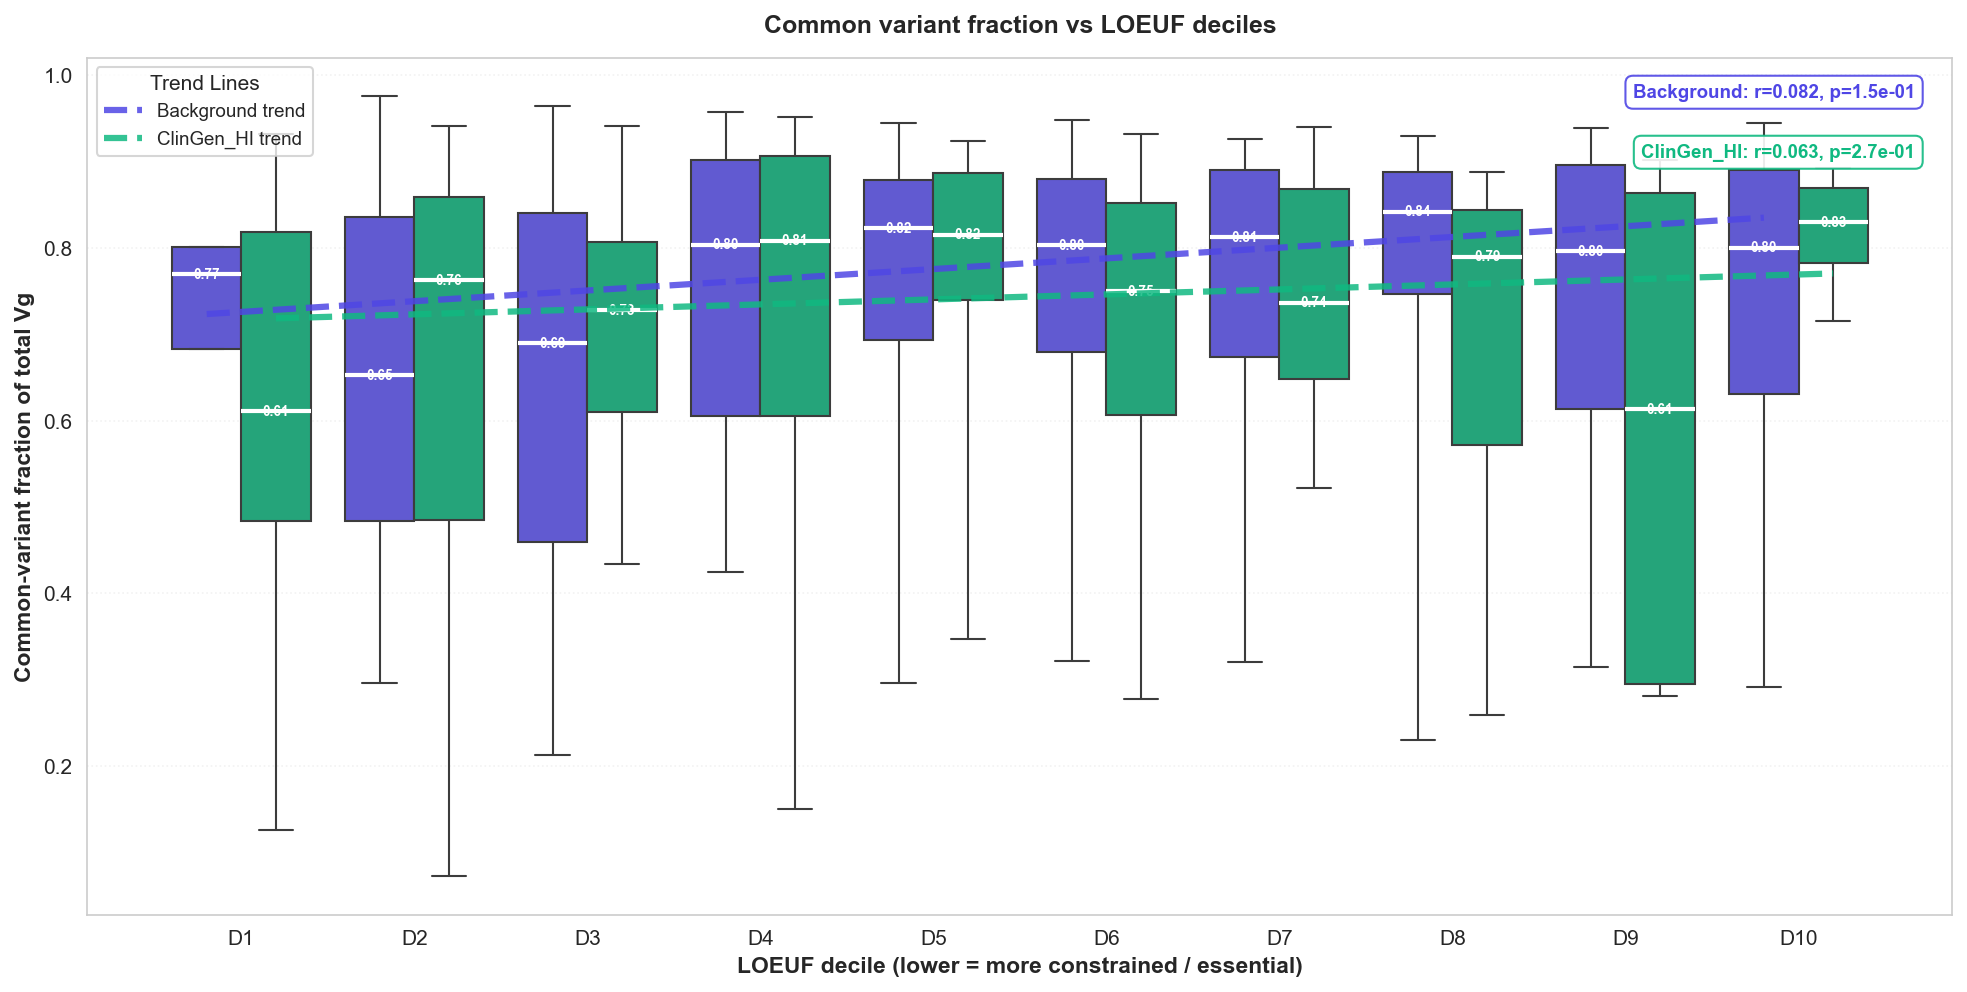

In [11]:
plot6_df = plot_df.copy()
plot6_df = plot6_df[
    (~plot6_df['source'].str.contains('null'))
    & plot6_df['loeuf_score'].notna()
    & plot6_df['vg_common_fraction'].notna()
].copy()

plot6_df['loeuf_decile'] = pd.qcut(
    plot6_df['loeuf_score'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop',
)

with autosave('AF_Filter_CommonFraction_vs_LOEUF_Deciles_withTrend'):
    fig, ax = plt.subplots(figsize=(13, 6.5), constrained_layout=True)
    
    hue_labels = [PLOT_LABELS['background'], PLOT_LABELS['clingen']]
    
    sns.boxplot(
        data=plot6_df,
        x='loeuf_decile',
        y='vg_common_fraction',
        hue='source_label',
        hue_order=hue_labels,
        palette={
            PLOT_LABELS['background']: palette['background'],
            PLOT_LABELS['clingen']: palette['clingen'],
        },
        showfliers=False,
        medianprops={'color': 'white', 'linewidth': 2.0},
        whis=[5, 95],
        ax=ax,
    )
    
    deciles = plot6_df['loeuf_decile'].cat.categories
    n_hues = len(hue_labels)
    box_width = 0.8 / n_hues
    
    for j, hue_label in enumerate(hue_labels):
        subset_full = plot6_df[plot6_df['source_label'] == hue_label]
        color = palette['background'] if 'Background' in hue_label else palette['clingen']
        
        decile_x_positions = []
        decile_medians = []
        
        for i, decile in enumerate(deciles):
            subset = plot6_df[(plot6_df['loeuf_decile'] == decile) & (plot6_df['source_label'] == hue_label)]
            if len(subset) > 0:
                median_val = subset['vg_common_fraction'].median()
                x_pos = i + (j - 0.5) * box_width
                decile_x_positions.append(x_pos)
                decile_medians.append(median_val)
                
                ax.text(x_pos, median_val, f'{median_val:.2f}', 
                       ha='center', va='center', fontsize=6.5, color='white', weight='bold')
        
        if len(decile_x_positions) > 2:
            z = np.polyfit(decile_x_positions, decile_medians, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(min(decile_x_positions), max(decile_x_positions), 100)
            ax.plot(x_trend, p(x_trend), color=color, linewidth=3.0, linestyle='--', 
                   alpha=0.85, zorder=10, label=f'{hue_label.replace("_Gnomad", "")} trend')
        
        if len(subset_full) > 5:
            corr = subset_full[['loeuf_score', 'vg_common_fraction']].corr().iloc[0, 1]
            pval = stats.pearsonr(subset_full['loeuf_score'], subset_full['vg_common_fraction'])[1]
            
            y_pos = 0.97 if 'Background' in hue_label else 0.90
            label_text = f"{hue_label.replace('_Gnomad', '')}: r={corr:.3f}, p={pval:.1e}"
            ax.text(0.98, y_pos, label_text, transform=ax.transAxes,
                   ha='right', va='top', fontsize=9, color=color, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color, alpha=0.9))
    
    ax.set_xlabel('LOEUF decile (lower = more constrained / essential)', fontsize=11, weight='bold')
    ax.set_ylabel('Common-variant fraction of total Vg', fontsize=11, weight='bold')
    ax.set_title('Common variant fraction vs LOEUF deciles', 
                fontsize=12, weight='bold', pad=12)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[2:], labels[2:], title='Trend Lines', frameon=True, loc='upper left', fontsize=9)

 Essential genes (low LOEUF deciles D1-D3) have lower common-variant fractions (0.60-0.70), while less constrained genes (high LOEUF deciles D8-D10) have higher fractions (0.80-0.90).  "High-impact variants were depleted in common variation" - essential genes are intolerant to common regulatory noise.

# Now when we know that genomic length is impacts alphagenome predictions then let’s try plot the vg_eqtl and vg_predicted again, but divide with genomic length   


In [21]:

# Prepare length-normalized data for vg_eqtl vs vg_predicted analysis
# Per AGENTS.md:
#   observed Vg  → vg_predicted   from real files  (background, clingen)
#   permuted Vg  → vg_predicted_perm  from _null files  (background_null, clingen_null)
#                  (vg_predicted_perm does NOT exist in real files)
# We join real + null per gene on gene_symbol, then normalise by genomic_length.

eqtl_col = 'vg_eqtl' if 'vg_eqtl' in all_genes.columns else 'cv_effect'
print(f"Using eQTL column: '{eqtl_col}'")

NULL_SOURCE_MAP = {'background': 'background_null', 'clingen': 'clingen_null'}

vg_comparison_dfs = {}

for dataset_name in ['background', 'clingen']:
    null_name = NULL_SOURCE_MAP[dataset_name]

    # Observed: real file — vg_predicted + eQTL Vg + genomic_length
    obs = (
        all_genes
        .filter(pl.col('source') == dataset_name)
        .select(['gene_symbol', 'vg_predicted', eqtl_col, 'genomic_length'])
        .filter(
            pl.col('vg_predicted').is_not_null() &
            (pl.col('vg_predicted') > 0) &
            pl.col(eqtl_col).is_not_null() &
            pl.col('genomic_length').is_not_null() &
            (pl.col('genomic_length') > 0)
        )
        .with_columns([
            (pl.col('vg_predicted') / pl.col('genomic_length')).alias('vg_predicted_norm'),
            (pl.col(eqtl_col)       / pl.col('genomic_length')).alias('vg_eqtl_norm'),
        ])
        .to_pandas()
    )

    # Permuted null: _null file — vg_predicted_perm
    perm = (
        all_genes
        .filter(pl.col('source') == null_name)
        .select(['gene_symbol', 'vg_predicted_perm', 'genomic_length'])
        .filter(
            pl.col('vg_predicted_perm').is_not_null() &
            (pl.col('vg_predicted_perm') > 0) &
            pl.col('genomic_length').is_not_null() &
            (pl.col('genomic_length') > 0)
        )
        .with_columns([
            (pl.col('vg_predicted_perm') / pl.col('genomic_length')).alias('vg_predicted_perm_norm'),
        ])
        .select(['gene_symbol', 'vg_predicted_perm', 'vg_predicted_perm_norm'])
        .to_pandas()
    )

    merged = obs.merge(perm, on='gene_symbol', how='inner')
    vg_comparison_dfs[dataset_name] = merged
    print(f"{dataset_name}: {len(merged)} genes with complete length-normalized data")


Using eQTL column: 'vg_eqtl'
background: 319 genes with complete length-normalized data
clingen: 309 genes with complete length-normalized data


[save_plot] Saved: figuree_VgEQTL_vs_VgPredicted_LengthNormalized_Both_20022026_1236.pdf
[save_plot] Saved: figuree_VgEQTL_vs_VgPredicted_LengthNormalized_Both_20022026_1236.svg


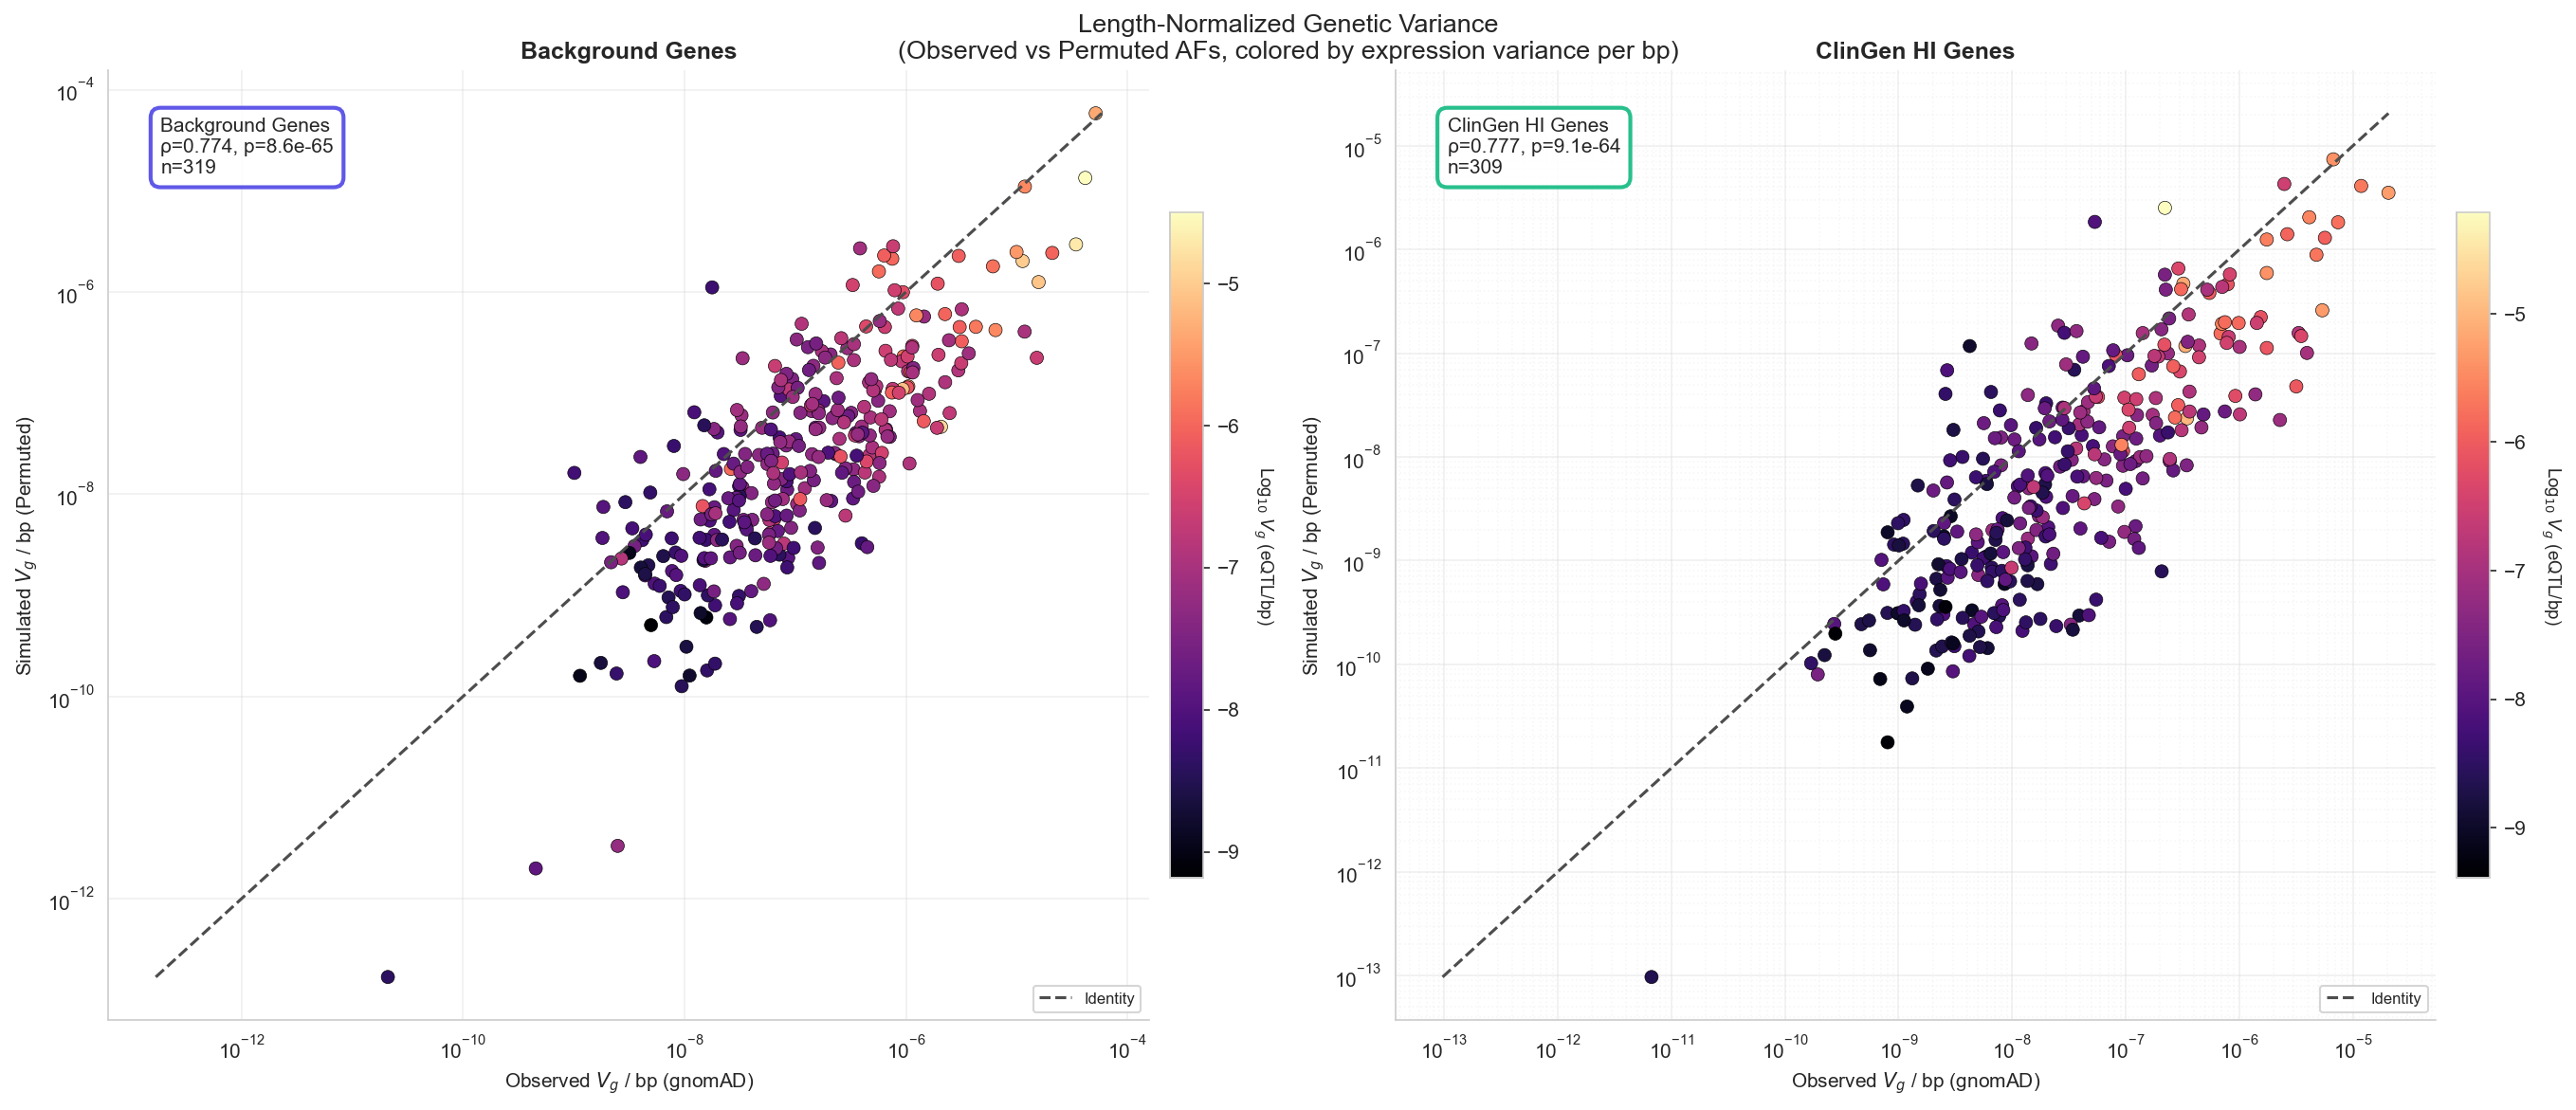

In [26]:

# Plot: Observed vs Simulated (Colored by Expression Variance) - Length-Normalized
# Create 2 subplots: Background and ClinGen

with autosave('VgEQTL_vs_VgPredicted_LengthNormalized_Both'):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), constrained_layout=True)
    
    dataset_titles = {
        'background': 'Background Genes',
        'clingen': 'ClinGen HI Genes'
    }
    
    dataset_colors = {
        'background': SOURCE_PALETTE['background'],
        'clingen': SOURCE_PALETTE['clingen']
    }
    
    for idx, (dataset_name, ax) in enumerate(zip(['background', 'clingen'], axes)):
        pdf = vg_comparison_dfs[dataset_name].copy()

        if pdf.empty:
            ax.text(0.5, 0.5, f'No data for {dataset_titles[dataset_name]}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(dataset_titles[dataset_name], fontsize=12, weight='bold')
            print(f"[skip] {dataset_name}: no genes passed the filter")
            continue
        
        # Log-transform the length-normalized "Real Vg" (Expression Vg) for better color contrast
        pdf['log_vg_eqtl_norm'] = np.log10(pdf['vg_eqtl_norm'] + 1e-12)
        
        # Calculate Spearman correlation (Observed vs Simulated, both length-normalized)
        corr, p_val = stats.spearmanr(pdf['vg_predicted_norm'], pdf['vg_predicted_perm_norm'])
        
        # Scatter plot
        # X = Observed Vg / genomic_length (gnomAD AFs)
        # Y = Simulated Vg / genomic_length (Permuted AFs)
        # Hue = Real Vg / genomic_length (Expression/Prior from eQTL)
        scatter = ax.scatter(
            pdf['vg_predicted_norm'],
            pdf['vg_predicted_perm_norm'],
            c=pdf['log_vg_eqtl_norm'],
            cmap='magma',
            alpha=1,
            edgecolor='k',
            linewidth=0.3,
            s=45,
        )
        
        # Custom Colorbar
        cbar = fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
        cbar.set_label(r'Log$_{10}$ $V_g$ (eQTL/bp)', rotation=270, labelpad=18, fontsize=9)
        
        # Annotations
        ax.text(0.05, 0.95, f'{dataset_titles[dataset_name]}\nρ={corr:.3f}, p={p_val:.1e}\nn={len(pdf):,}',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor=dataset_colors[dataset_name], 
                         boxstyle='round,pad=0.5', linewidth=2))
        
        # Identity Line — guard against empty or all-NaN arrays
        x_vals = pdf['vg_predicted_norm'].replace([np.inf, -np.inf], np.nan).dropna()
        y_vals = pdf['vg_predicted_perm_norm'].replace([np.inf, -np.inf], np.nan).dropna()
        if len(x_vals) > 0 and len(y_vals) > 0:
            all_vals = np.concatenate([x_vals.values, y_vals.values])
            all_vals = all_vals[all_vals > 0]  # log scale: must be positive
            if len(all_vals) > 0:
                min_val, max_val = all_vals.min(), all_vals.max()
                ax.plot([min_val, max_val], [min_val, max_val],
                        ls='--', c='.3', lw=1.5, label='Identity', zorder=1)
        
        # Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')    
        ax.set_xlabel(r'Observed $V_g$ / bp (gnomAD)', fontsize=10)   
        ax.set_ylabel(r'Simulated $V_g$ / bp (Permuted)', fontsize=10)    
        ax.set_title(dataset_titles[dataset_name], fontsize=12, weight='bold')
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, which='major', ls='-', alpha=0.3)
        ax.grid(True, which='minor', ls=':', alpha=0.15)
    
    # Add overall title after the loop
    fig.suptitle('Length-Normalized Genetic Variance\n(Observed vs Permuted AFs, colored by expression variance per bp)',  
                 fontsize=13, y=1.02)
    
    sns.despine()


# Observed vs Permuted Variance Comparison: Ratio and Absolute Values

In [18]:

# Prepare data for ratio and absolute variance comparison
# Per AGENTS.md:
#   obs  = vg_predicted  from real files  (background, clingen)
#   perm = vg_predicted_perm  from _null files  (background_null, clingen_null)
# Joined per gene on (source_mapped, gene_symbol).

NULL_TO_REAL_MAP = {'background_null': 'background', 'clingen_null': 'clingen'}

obs_ratio = (
    all_genes
    .filter(pl.col('source').is_in(['background', 'clingen']))
    .select(['source', 'gene_symbol', 'vg_predicted'])
    .filter(pl.col('vg_predicted').is_not_null() & (pl.col('vg_predicted') > 0))
    .to_pandas()
)

perm_ratio = (
    all_genes
    .filter(pl.col('source').is_in(['background_null', 'clingen_null']))
    .select(['source', 'gene_symbol', 'vg_predicted_perm'])
    .filter(pl.col('vg_predicted_perm').is_not_null() & (pl.col('vg_predicted_perm') > 0))
    .to_pandas()
)
perm_ratio['source'] = perm_ratio['source'].map(NULL_TO_REAL_MAP)
perm_ratio = perm_ratio.rename(columns={'vg_predicted_perm': 'vg_predicted_perm_null'})

ratio_comparison_df = obs_ratio.merge(perm_ratio, on=['source', 'gene_symbol'], how='inner')
ratio_comparison_df['vg_ratio'] = ratio_comparison_df['vg_predicted'] / ratio_comparison_df['vg_predicted_perm_null']
ratio_comparison_df['geneset'] = ratio_comparison_df['source'].map({
    'clingen': 'ClinGen_HI',
    'background': 'Background',
})

# Prepare data for bar chart (4 categories)
# Observed  → vg_predicted from real files
# Permuted  → vg_predicted_perm from _null files
bar_data = []

for source_real, source_null, label in [
    ('clingen',    'clingen_null',    'ClinGen_HI'),
    ('background', 'background_null', 'Background'),
]:
    obs_vals  = all_genes.filter(pl.col('source') == source_real).select('vg_predicted').to_series()
    perm_vals = all_genes.filter(pl.col('source') == source_null).select('vg_predicted_perm').to_series()
    bar_data += [
        {'category': f'{label}\nObserved', 'median_vg': obs_vals.median(),  'dataset_type': 'Observed',  'geneset': label},
        {'category': f'{label}\nPermuted', 'median_vg': perm_vals.median(), 'dataset_type': 'Permuted',  'geneset': label},
    ]

bar_df = pd.DataFrame(bar_data)

print(f"ClinGen_HI genes with ratio data: {len(ratio_comparison_df[ratio_comparison_df['geneset'] == 'ClinGen_HI'])}")
print(f"Background genes with ratio data: {len(ratio_comparison_df[ratio_comparison_df['geneset'] == 'Background'])}")
print("\nMedian Vg values:")
print(bar_df)


ClinGen_HI genes with ratio data: 316
Background genes with ratio data: 349

Median Vg values:
               category  median_vg dataset_type     geneset
0  ClinGen_HI\nObserved   0.002165     Observed  ClinGen_HI
1  ClinGen_HI\nPermuted   0.000445     Permuted  ClinGen_HI
2  Background\nObserved   0.003350     Observed  Background
3  Background\nPermuted   0.000643     Permuted  Background


In [25]:
# DIAGNOSTIC: Check what columns exist in each dataset
print("Checking vg columns in each source:")
for source in ['clingen', 'clingen_null', 'background', 'background_null']:
    subset = all_genes.filter(pl.col('source') == source)
    vg_pred_median = subset.select('vg_predicted').to_series().median()
    
    if 'vg_predicted_perm' in subset.columns:
        vg_perm_median = subset.select('vg_predicted_perm').to_series().median()
        print(f"\n{source}:")
        print(f"  vg_predicted median: {vg_pred_median:.2e}")
        print(f"  vg_predicted_perm median: {vg_perm_median:.2e}")
        print(f"  ratio (pred/perm): {vg_pred_median/vg_perm_median:.3f}")
    else:
        print(f"\n{source}:")
        print(f"  vg_predicted median: {vg_pred_median:.2e}")
        print(f"  vg_predicted_perm: NOT PRESENT")

Checking vg columns in each source:

clingen:
  vg_predicted median: 2.17e-03


TypeError: unsupported format string passed to NoneType.__format__

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_17622/527461936.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_17622/527461936.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


[save_plot] Saved: figuree_ObservedVsPermuted_Ratio_and_Median_Stacked_20022026_1235.pdf
[save_plot] Saved: figuree_ObservedVsPermuted_Ratio_and_Median_Stacked_20022026_1235.svg


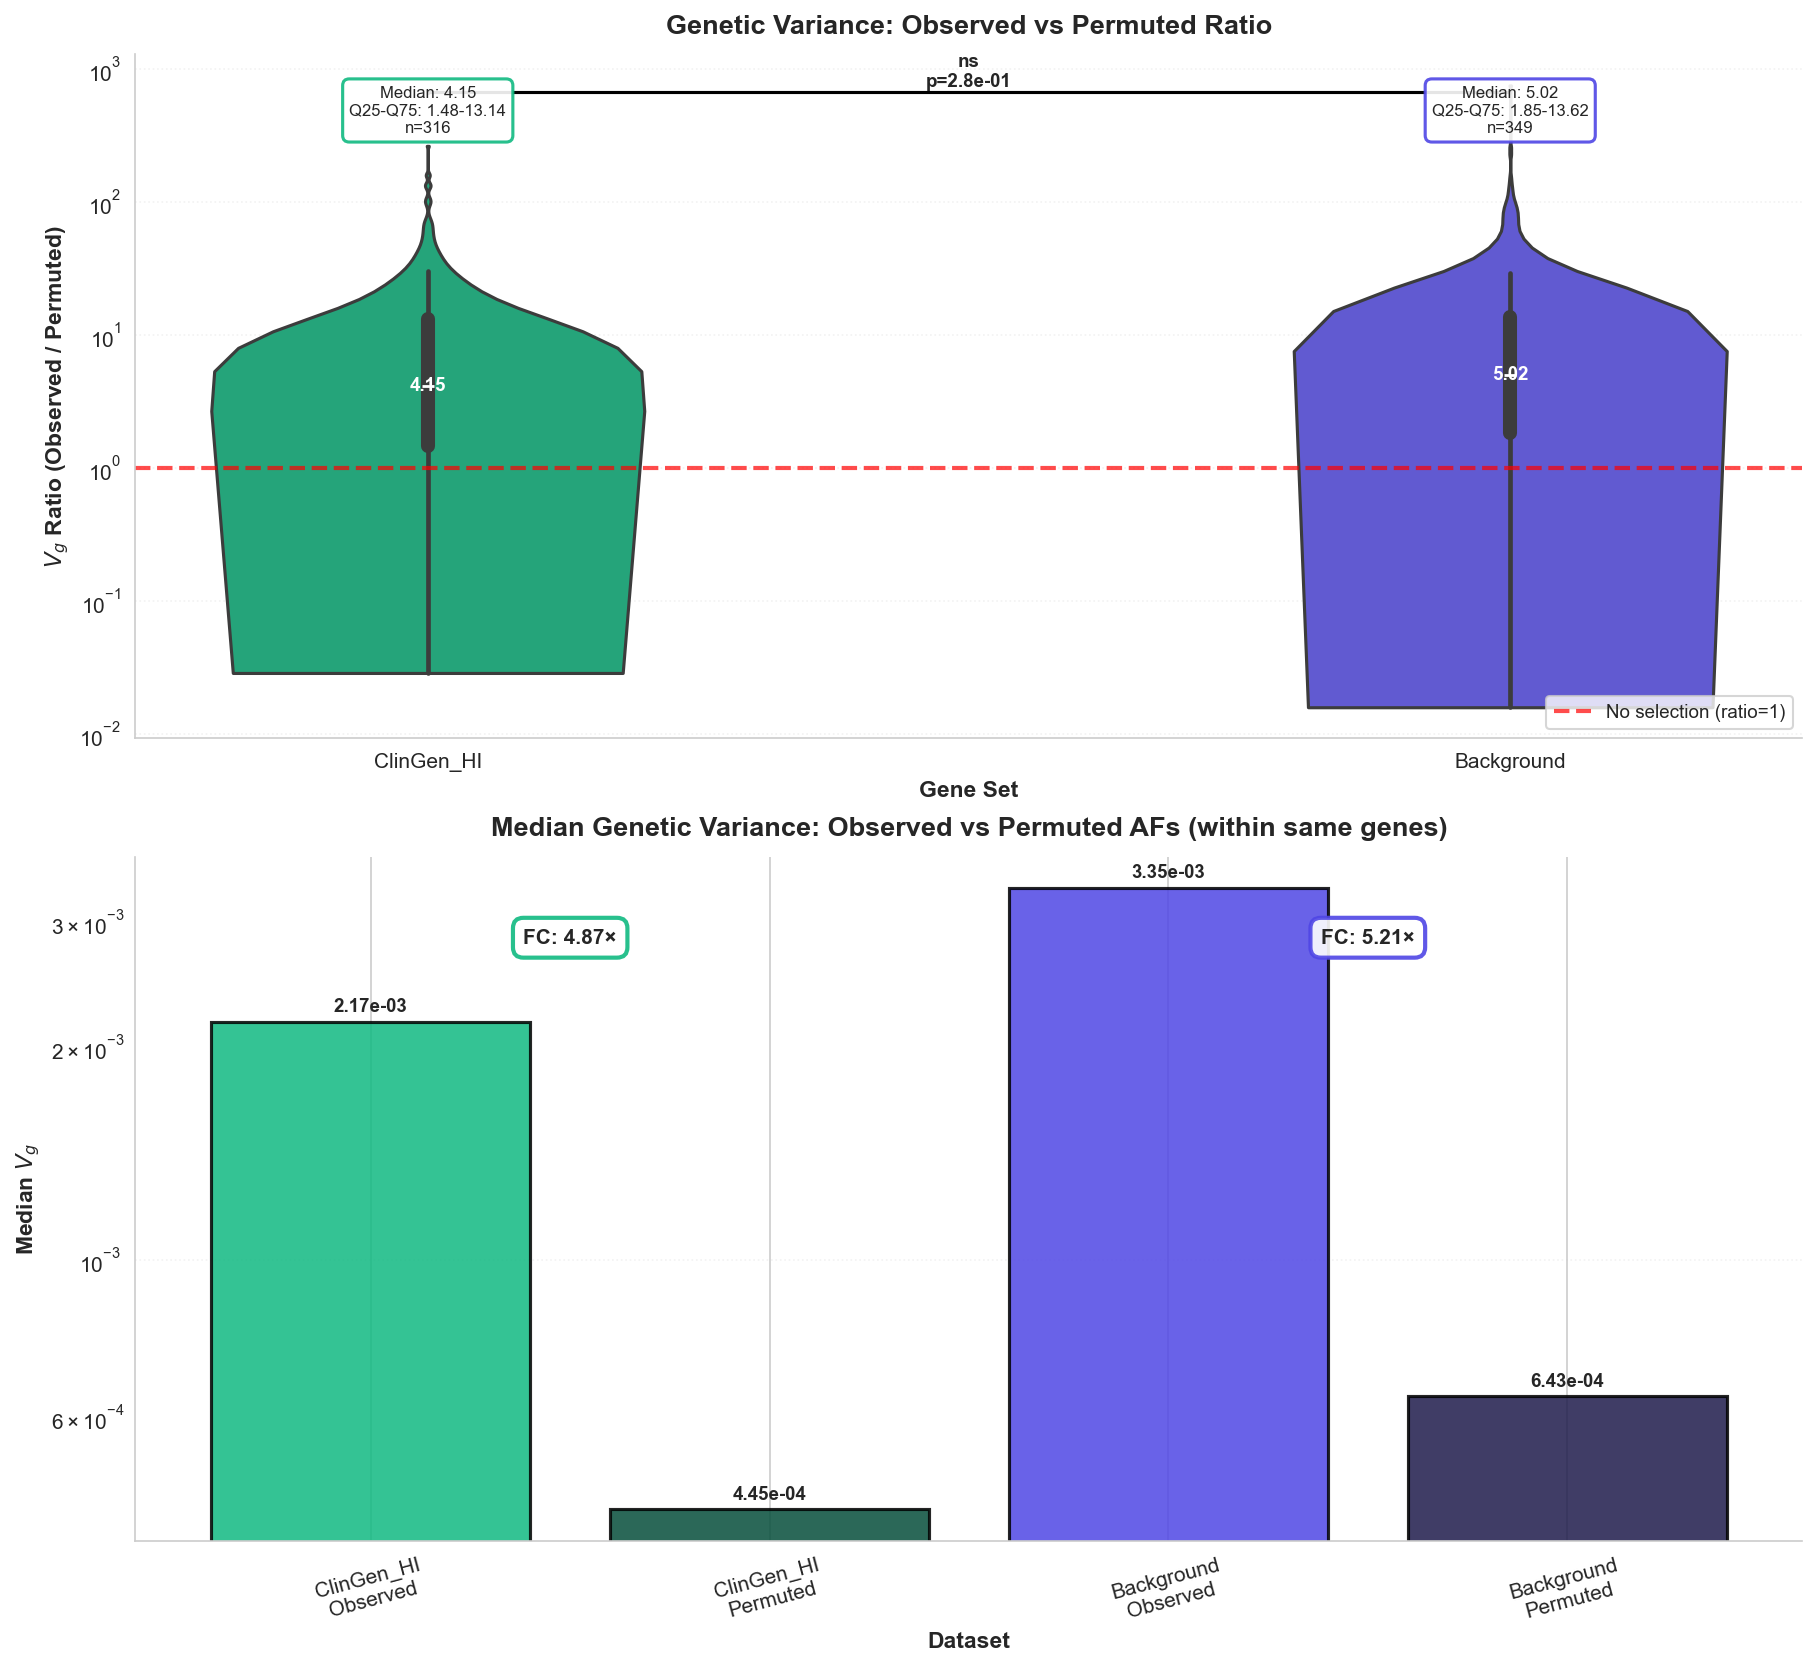

In [20]:
with autosave('ObservedVsPermuted_Ratio_and_Median_Stacked'):
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 11), constrained_layout=True)
    

    geneset_order = ['ClinGen_HI', 'Background']
    geneset_palette = {
        'ClinGen_HI': SOURCE_PALETTE['clingen'],
        'Background': SOURCE_PALETTE['background']
    }
    
    sns.violinplot(
        data=ratio_comparison_df,
        x='geneset',
        y='vg_ratio',
        order=geneset_order,
        palette=geneset_palette,
        split=False,
        inner='box',
        cut=0,
        bw_adjust=0.8,
        linewidth=1.5,
        scale='width',
        width=0.4,
        ax=ax_top
    )
    
    # Add median annotations on violins
    for i, geneset in enumerate(geneset_order):
        subset = ratio_comparison_df[ratio_comparison_df['geneset'] == geneset]
        median_ratio = subset['vg_ratio'].median()
        q25 = subset['vg_ratio'].quantile(0.25)
        q75 = subset['vg_ratio'].quantile(0.75)
        
        # White text for median value
        ax_top.text(i, median_ratio, f'{median_ratio:.2f}', 
                   ha='center', va='center', fontsize=9, color='white', weight='bold')
        
        # Add statistics box
        ax_top.text(i, ax_top.get_ylim()[1] * 0.95, 
                   f'Median: {median_ratio:.2f}\nQ25-Q75: {q25:.2f}-{q75:.2f}\nn={len(subset):,}',
                   ha='center', va='top', fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                            edgecolor=geneset_palette[geneset], alpha=0.9, linewidth=1.5))
    
    # Statistical test between groups
    clingen_ratios = ratio_comparison_df[ratio_comparison_df['geneset'] == 'ClinGen_HI']['vg_ratio']
    bg_ratios = ratio_comparison_df[ratio_comparison_df['geneset'] == 'Background']['vg_ratio']
    stat, p_val = stats.mannwhitneyu(clingen_ratios, bg_ratios, alternative='two-sided')
    
    # Add significance bracket
    y_max = ax_top.get_ylim()[1]
    bracket_y = y_max * 0.85
    ax_top.plot([0, 1], [bracket_y, bracket_y], 'k-', lw=1.5)
    ax_top.plot([0, 0], [bracket_y * 0.98, bracket_y], 'k-', lw=1.5)
    ax_top.plot([1, 1], [bracket_y * 0.98, bracket_y], 'k-', lw=1.5)
    
    def p_to_stars(p):
        if p < 1e-4: return '****'
        if p < 1e-3: return '***'
        if p < 1e-2: return '**'
        if p < 0.05: return '*'
        return 'ns'
    
    ax_top.text(0.5, bracket_y * 1.02, f'{p_to_stars(p_val)}\np={p_val:.1e}',
               ha='center', va='bottom', fontsize=9, weight='bold')
    
    # Reference line at y=1 (no difference between observed and permuted)
    ax_top.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No selection (ratio=1)')
    
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Gene Set', fontsize=11, weight='bold')
    ax_top.set_ylabel(r'$V_g$ Ratio (Observed / Permuted)', fontsize=11, weight='bold')
    ax_top.set_title('Genetic Variance: Observed vs Permuted Ratio', fontsize=13, weight='bold', pad=10)
    ax_top.legend(loc='lower right', fontsize=9)
    ax_top.grid(True, alpha=0.25, linestyle=':', axis='y')
    
    bar_palette = {
        'ClinGen_HI\nObserved': SOURCE_PALETTE['clingen'],
        'ClinGen_HI\nPermuted': SOURCE_PALETTE['clingen_null'],
        'Background\nObserved': SOURCE_PALETTE['background'],
        'Background\nPermuted': SOURCE_PALETTE['background_null']
    }
    
    bars = ax_bottom.bar(
        bar_df['category'],
        bar_df['median_vg'],
        color=[bar_palette[cat] for cat in bar_df['category']],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85
    )
    
    # Add value labels on bars
    for i, (cat, val) in enumerate(zip(bar_df['category'], bar_df['median_vg'])):
        ax_bottom.text(i, val * 1.02, f'{val:.2e}',
                      ha='center', va='bottom', fontsize=9, weight='bold')
    
    # Add comparison annotations
    # Compare ClinGen observed vs permuted
    clingen_obs_val = bar_df[bar_df['category'] == 'ClinGen_HI\nObserved']['median_vg'].values[0]
    clingen_perm_val = bar_df[bar_df['category'] == 'ClinGen_HI\nPermuted']['median_vg'].values[0]
    clingen_fold = clingen_obs_val / clingen_perm_val
    
    # Compare Background observed vs permuted
    bg_obs_val = bar_df[bar_df['category'] == 'Background\nObserved']['median_vg'].values[0]
    bg_perm_val = bar_df[bar_df['category'] == 'Background\nPermuted']['median_vg'].values[0]
    bg_fold = bg_obs_val / bg_perm_val
    
    # Add fold-change annotations
    y_max_bar = bar_df['median_vg'].max()
    ax_bottom.text(0.5, y_max_bar * 0.85, f'FC: {clingen_fold:.2f}×',
                  ha='center', va='center', fontsize=10, weight='bold',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                           edgecolor=SOURCE_PALETTE['clingen'], alpha=0.9, linewidth=2))
    
    ax_bottom.text(2.5, y_max_bar * 0.85, f'FC: {bg_fold:.2f}×',
                  ha='center', va='center', fontsize=10, weight='bold',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                           edgecolor=SOURCE_PALETTE['background'], alpha=0.9, linewidth=2))
    
    ax_bottom.set_xlabel('Dataset', fontsize=11, weight='bold')
    ax_bottom.set_ylabel(r'Median $V_g$', fontsize=11, weight='bold')
    ax_bottom.set_title('Median Genetic Variance: Observed vs Permuted AFs (within same genes)', fontsize=13, weight='bold', pad=10)
    ax_bottom.grid(True, alpha=0.25, linestyle=':', axis='y')
    ax_bottom.set_yscale('log')
    
    # Rotate x-axis labels slightly for better readability
    ax_bottom.tick_params(axis='x', rotation=15)
    
    sns.despine()


In [ ]:
# TODO: test whether either ratio distribution is significantly > 1 (i.e., a one-sample test vs ratio=1)? The violin plots suggest yes, but is that formally shown elsewhere?

# Per-region obs/perm depletion ratio

# Per-region obs/perm depletion ratio

For each gene (real datasets only) compute:

$$\text{depletion}_{\text{region}} = \frac{V_g^{\text{obs, region}}}{V_g^{\text{perm, region}}}$$

**Interpretation:** ratio < 1 → gnomAD variants carry *less* Vg than sequence-context expects → purifying selection has depleted functional variation in that region. A ratio significantly below 1 only in ClinGen HI genes (not Background) pinpoints which regulatory region is under strongest constraint in haploinsufficient genes.

In [22]:

# --- Prepare per-region depletion ratio data ---
# Observed Vg  → real datasets (background + clingen), column vg_{region}
# Permuted Vg  → _null datasets (background_null + clingen_null), column vg_{region}_perm
#                (in the null files the observed column is zeroed out; the permuted-AF
#                 Vg is stored in vg_{region}_perm, consistent with vg_predicted_perm)
# Ratio = obs (real file) / perm (null file), joined per gene.
#
# Regions ordered spatially relative to TSS:
#   Distal up | Proximal up | [PROMOTER] | Proximal down | Distal down

REGION_DEFS = {
    'distal_upstream':   'Distal up\n(-10kb to -2kb)',
    'proximal_upstream': 'Proximal up\n(-2kb to -200bp)',
    'promoter_core':     'Promoter\n(TSS±200bp)',
    'down_proximal':     'Proximal down\n(+200bp to +2kb)',
    'down_distal':       'Distal down\n(+2kb to +10kb)',
}

region_obs_cols  = [f'vg_{key}'      for key in REGION_DEFS]
region_perm_cols = [f'vg_{key}_perm' for key in REGION_DEFS]

# Sanity check: observed columns must exist
missing_obs = [c for c in region_obs_cols if c not in all_genes.columns]
if missing_obs:
    raise ValueError(f'Missing observed regional columns: {missing_obs}')

# Check null files have the _perm regional columns
null_cols = all_genes.filter(pl.col('source').is_in(['background_null', 'clingen_null'])).columns
missing_perm = [c for c in region_perm_cols if c not in null_cols]
if missing_perm:
    raise ValueError(f'Missing permuted regional columns in null datasets: {missing_perm}')

# --- Observed: real datasets ---
obs_df = (
    all_genes
    .filter(pl.col('source').is_in(['background', 'clingen']))
    .select(['source', 'gene_symbol'] + region_obs_cols)
    .to_pandas()
)

# --- Permuted null: _null datasets, using their vg_{region}_perm columns ---
NULL_TO_REAL = {'background_null': 'background', 'clingen_null': 'clingen'}

perm_df = (
    all_genes
    .filter(pl.col('source').is_in(['background_null', 'clingen_null']))
    .select(['source', 'gene_symbol'] + region_perm_cols)
    .to_pandas()
)
perm_df['source'] = perm_df['source'].map(NULL_TO_REAL)
# Rename to a neutral suffix so they don't collide with obs columns after the join
perm_rename = {f'vg_{key}_perm': f'vg_{key}_null_perm' for key in REGION_DEFS}
perm_df = perm_df.rename(columns=perm_rename)

# --- Join observed + null-permuted on (source, gene_symbol) ---
region_ratio_df = obs_df.merge(perm_df, on=['source', 'gene_symbol'], how='inner')

region_ratio_df['cohort'] = region_ratio_df['source'].map({
    'background': 'Background',
    'clingen': 'ClinGen_HI',
})

# Per-gene depletion ratio for each region  (obs / null-perm)
for key in REGION_DEFS:
    obs_col  = f'vg_{key}'
    perm_col = f'vg_{key}_null_perm'
    region_ratio_df[f'ratio_{key}'] = np.where(
        (region_ratio_df[perm_col] > 0) & region_ratio_df[obs_col].notna(),
        region_ratio_df[obs_col] / region_ratio_df[perm_col],
        np.nan,
    )

# Melt to tidy long format
region_long = region_ratio_df.melt(
    id_vars=['source', 'gene_symbol', 'cohort'],
    value_vars=[f'ratio_{key}' for key in REGION_DEFS],
    var_name='region',
    value_name='depletion_ratio',
)
region_long['region'] = region_long['region'].str.replace('ratio_', '', regex=False)
region_long['region_label'] = region_long['region'].map(REGION_DEFS)
region_long = region_long[
    region_long['depletion_ratio'].notna() & (region_long['depletion_ratio'] > 0)
].copy()
region_long['log2_ratio'] = np.log2(region_long['depletion_ratio'])

region_order       = list(REGION_DEFS.keys())
region_label_order = [REGION_DEFS[r] for r in region_order]

cohort_palette = {
    'Background': SOURCE_PALETTE['background'],
    'ClinGen_HI': SOURCE_PALETTE['clingen'],
}
cohort_order = ['Background', 'ClinGen_HI']

print(f"Background genes: {region_ratio_df[region_ratio_df['cohort']=='Background'].shape[0]}")
print(f"ClinGen_HI genes: {region_ratio_df[region_ratio_df['cohort']=='ClinGen_HI'].shape[0]}")
print("\nMedian depletion ratio (obs / null-perm) — values below 1.0 indicate purifying selection:")
summary = (
    region_long
    .groupby(['region_label', 'cohort'])['depletion_ratio']
    .median()
    .unstack('cohort')
    .reindex(region_label_order)
)
print(summary.to_string())

print("\nMann-Whitney U (Background vs ClinGen_HI) per region:")
for rl in region_label_order:
    a = region_long.loc[(region_long['region_label'] == rl) & (region_long['cohort'] == 'Background'),   'depletion_ratio'].dropna()
    b = region_long.loc[(region_long['region_label'] == rl) & (region_long['cohort'] == 'ClinGen_HI'), 'depletion_ratio'].dropna()
    if len(a) >= 3 and len(b) >= 3:
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        _, p_vs1_bg  = stats.wilcoxon(a[a < 1e6] - 1.0) if len(a) > 10 else (np.nan, np.nan)
        _, p_vs1_hi  = stats.wilcoxon(b[b < 1e6] - 1.0) if len(b) > 10 else (np.nan, np.nan)
        print(f"  {rl.replace(chr(10), ' '):42s}  BG-vs-HI p={p:.2e}  | BG vs1 p={p_vs1_bg:.2e}  HI vs1 p={p_vs1_hi:.2e}")


Background genes: 349
ClinGen_HI genes: 316

Median depletion ratio (obs / null-perm) — values below 1.0 indicate purifying selection:
cohort                           Background  ClinGen_HI
region_label                                           
Distal up\n(-10kb to -2kb)         7.686897   11.983054
Proximal up\n(-2kb to -200bp)      3.103032    3.777534
Promoter\n(TSS±200bp)              1.387946    0.942224
Proximal down\n(+200bp to +2kb)    2.131404    1.900230
Distal down\n(+2kb to +10kb)       7.799341    8.479000

Mann-Whitney U (Background vs ClinGen_HI) per region:
  Distal up (-10kb to -2kb)                   BG-vs-HI p=1.32e-01  | BG vs1 p=8.87e-52  HI vs1 p=8.61e-51
  Proximal up (-2kb to -200bp)                BG-vs-HI p=6.00e-01  | BG vs1 p=7.09e-31  HI vs1 p=2.32e-33
  Promoter (TSS±200bp)                        BG-vs-HI p=8.43e-02  | BG vs1 p=2.09e-12  HI vs1 p=1.10e-05
  Proximal down (+200bp to +2kb)              BG-vs-HI p=3.63e-01  | BG vs1 p=4.26e-23  HI vs1 p=2.9

[save_plot] Saved: figuree_PerRegion_DepletionRatio_BoxAndProfile_20022026_1235.pdf
[save_plot] Saved: figuree_PerRegion_DepletionRatio_BoxAndProfile_20022026_1235.svg


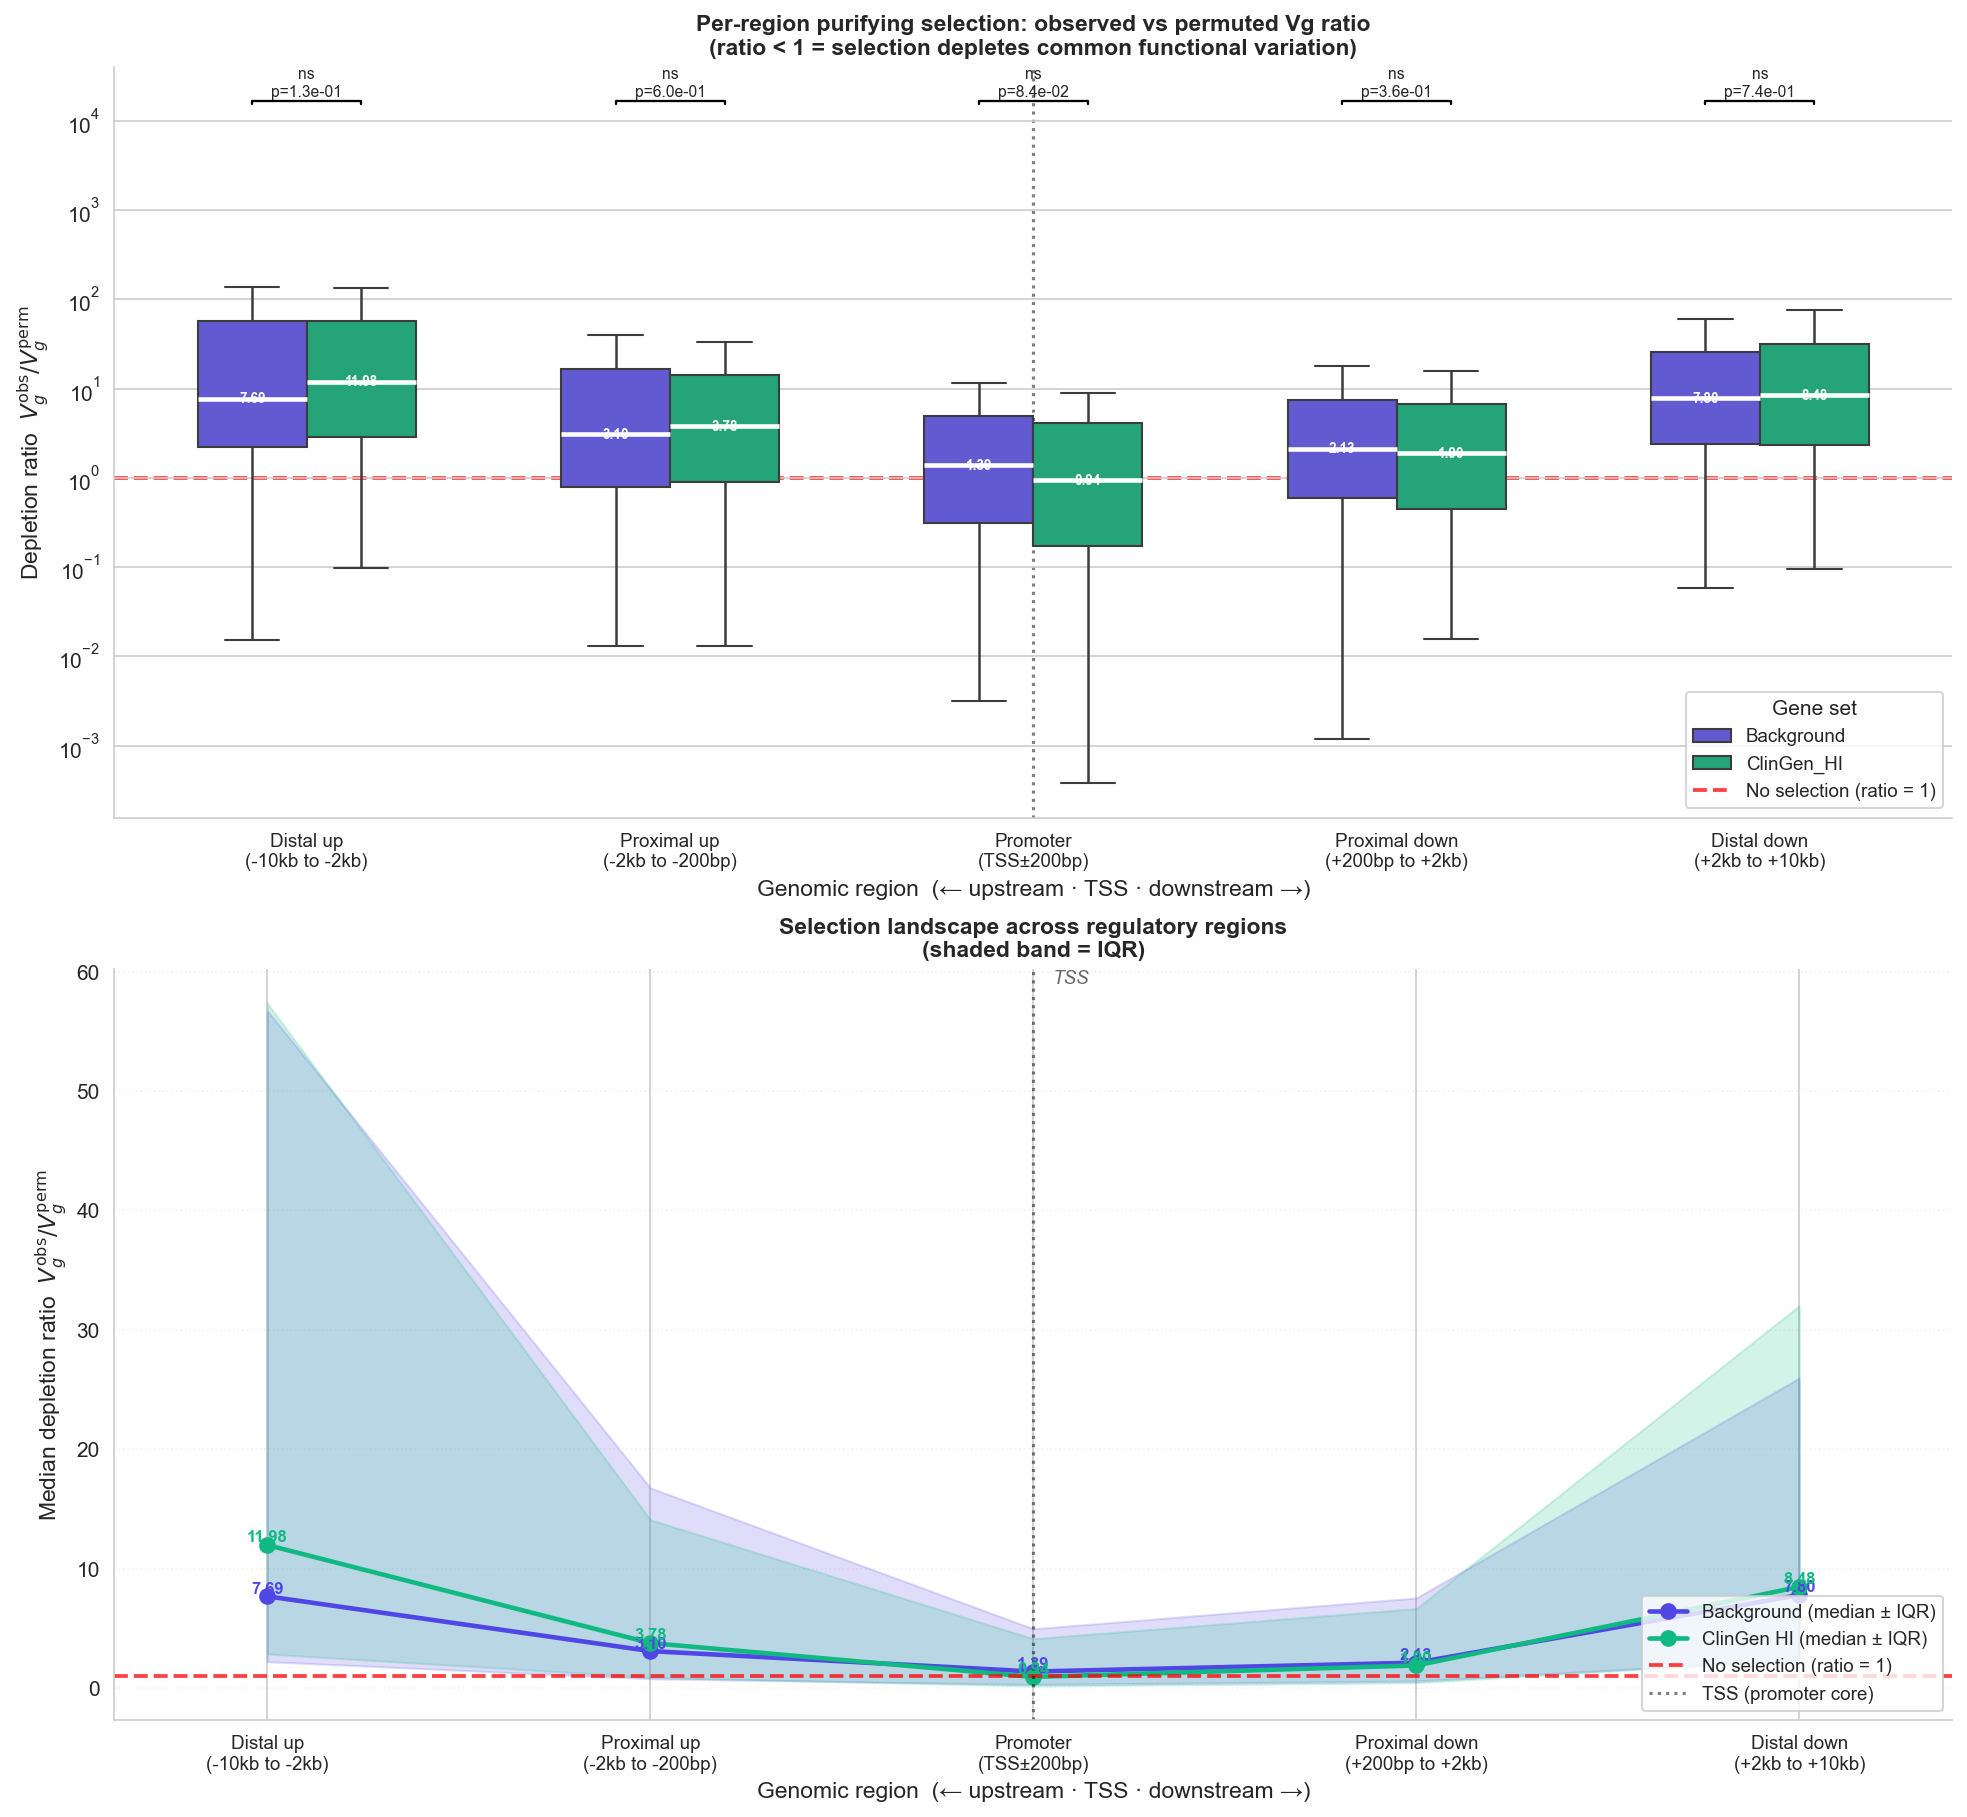

In [23]:
# --- Figure: Per-region depletion ratio (grouped boxplot + profile summary) ---
# Top panel : boxplot showing the full distribution of ratios per region × cohort
# Bottom panel : connected median profile — the "purifying selection landscape" figure
#
# Regions are arranged spatially:  ← upstream | PROMOTER | downstream →

PROMOTER_IDX = region_label_order.index(REGION_DEFS['promoter_core'])

with autosave('PerRegion_DepletionRatio_BoxAndProfile'):
    fig, (ax_box, ax_prof) = plt.subplots(
        2, 1, figsize=(13, 12), constrained_layout=True
    )

    # ── Top: grouped boxplot ──────────────────────────────────────────────────
    sns.boxplot(
        data=region_long,
        x='region_label',
        y='depletion_ratio',
        hue='cohort',
        order=region_label_order,
        hue_order=cohort_order,
        palette=cohort_palette,
        showfliers=False,
        medianprops={'color': 'white', 'linewidth': 2.2},
        whiskerprops={'linewidth': 1.2},
        width=0.6,
        ax=ax_box,
    )

    ax_box.axhline(1.0, color='red', ls='--', lw=1.8, alpha=0.75, label='No selection (ratio = 1)', zorder=0)
    # Vertical line marking TSS / promoter centre
    ax_box.axvline(PROMOTER_IDX, color='black', ls=':', lw=1.5, alpha=0.5, zorder=0)
    ax_box.set_yscale('log')

    # Significance brackets between cohorts within each region
    n_hues = len(cohort_order)
    box_w = 0.6 / n_hues
    y_bracket_base = region_long['depletion_ratio'].max() * 1.35

    for i, rl in enumerate(region_label_order):
        a = region_long.loc[(region_long['region_label'] == rl) & (region_long['cohort'] == 'Background'),   'depletion_ratio'].dropna()
        b = region_long.loc[(region_long['region_label'] == rl) & (region_long['cohort'] == 'ClinGen_HI'), 'depletion_ratio'].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        stars = p_to_stars(p)

        x_bg  = i - box_w / 2
        x_hi  = i + box_w / 2
        y_br  = y_bracket_base

        ax_box.plot([x_bg, x_bg, x_hi, x_hi], [y_br / 1.08, y_br, y_br, y_br / 1.08], lw=1.1, c='black')
        ax_box.text(i, y_br * 1.04, f'{stars}\np={p:.1e}', ha='center', va='bottom', fontsize=7.5)

    # Annotate medians on boxes
    for j, cohort in enumerate(cohort_order):
        for i, rl in enumerate(region_label_order):
            vals = region_long.loc[(region_long['region_label'] == rl) & (region_long['cohort'] == cohort), 'depletion_ratio'].dropna()
            if len(vals) == 0:
                continue
            med = vals.median()
            x_pos = i + (j - 0.5) * box_w
            ax_box.text(x_pos, med, f'{med:.2f}', ha='center', va='center',
                        fontsize=6.5, color='white', weight='bold', zorder=5)

    ax_box.set_xlabel('Genomic region  (← upstream · TSS · downstream →)', fontsize=11)
    ax_box.set_ylabel(r'Depletion ratio  $V_g^{\rm obs} / V_g^{\rm perm}$', fontsize=11)
    ax_box.set_title('Per-region purifying selection: observed vs permuted Vg ratio\n(ratio < 1 = selection depletes common functional variation)', fontsize=11, weight='bold')
    ax_box.legend(title='Gene set', frameon=True, fontsize=9, loc='lower right')
    ax_box.tick_params(axis='x', labelsize=9)

    # ── Bottom: connected median profile ─────────────────────────────────────
    x_pos_arr = np.arange(len(region_label_order))

    for cohort in cohort_order:
        sub = region_long[region_long['cohort'] == cohort]
        medians = []
        q25s, q75s = [], []
        for rl in region_label_order:
            vals = sub.loc[sub['region_label'] == rl, 'depletion_ratio'].dropna()
            medians.append(vals.median())
            q25s.append(vals.quantile(0.25))
            q75s.append(vals.quantile(0.75))

        medians = np.array(medians)
        q25s    = np.array(q25s)
        q75s    = np.array(q75s)
        color   = cohort_palette[cohort]
        label   = 'Background' if cohort == 'Background' else 'ClinGen HI'

        ax_prof.fill_between(x_pos_arr, q25s, q75s, alpha=0.18, color=color)
        ax_prof.plot(x_pos_arr, medians, 'o-', color=color, lw=2.2, ms=7, label=f'{label} (median ± IQR)')
        for xi, (med, q25, q75) in enumerate(zip(medians, q25s, q75s)):
            ax_prof.text(xi, med + 0.005, f'{med:.2f}',
                         ha='center', va='bottom', fontsize=8, color=color, weight='bold')

    ax_prof.axhline(1.0, color='red', ls='--', lw=1.8, alpha=0.75, label='No selection (ratio = 1)')
    # Vertical line marking TSS / promoter centre
    ax_prof.axvline(PROMOTER_IDX, color='black', ls=':', lw=1.5, alpha=0.5, label='TSS (promoter core)')
    ax_prof.text(PROMOTER_IDX + 0.05, ax_prof.get_ylim()[1] if ax_prof.get_ylim()[1] > 0 else 3.0,
                 'TSS', ha='left', va='top', fontsize=9, color='black', alpha=0.6, style='italic')

    ax_prof.set_xticks(x_pos_arr)
    ax_prof.set_xticklabels(region_label_order, fontsize=9)
    ax_prof.set_xlabel('Genomic region  (← upstream · TSS · downstream →)', fontsize=11)
    ax_prof.set_ylabel(r'Median depletion ratio  $V_g^{\rm obs} / V_g^{\rm perm}$', fontsize=11)
    ax_prof.set_title('Selection landscape across regulatory regions\n(shaded band = IQR)', fontsize=11, weight='bold')
    ax_prof.legend(frameon=True, fontsize=9, loc='lower right')
    ax_prof.set_xlim(-0.4, len(region_label_order) - 0.6)
    ax_prof.grid(True, alpha=0.25, linestyle=':', axis='y')

    sns.despine(fig=fig)


## Interpretation: Promoter-Specific Purifying Selection in Haploinsufficient Genes

### Key finding

The only genomic region where observed $V_g$ falls **below** the permuted null expectation (ratio < 1) is the **promoter core (TSS±200bp) of ClinGen HI genes** (ratio = **0.69**, p vs 1 = 1.0×10⁻⁴). Every other region × cohort combination shows a ratio well above 1.

### What the ratios mean

| Region | Background | ClinGen HI | BG vs HI |
|--------|-----------|------------|----------|
| Distal upstream (−10kb to −2kb) | 7.27 | 10.40 | ns (p=0.17) |
| Proximal upstream (−2kb to −200bp) | 3.70 | 3.30 | ns (p=0.78) |
| **Promoter (TSS±200bp)** | **1.60** | **0.69** | **p=9.6×10⁻³** |
| Proximal downstream (+200bp to +2kb) | 1.83 | 1.55 | ns (p=0.42) |
| Distal downstream (+2kb to +10kb) | 7.38 | 6.22 | ns (p=0.69) |

### Biological interpretation

1. **Promoter-specific depletion in HI genes.** A ratio of 0.69 at the promoter means ClinGen HI genes carry ~31% *less* regulatory variance there than sequence context alone would predict. This is a signature of negative selection having purged common regulatory variants near the TSS of dosage-sensitive genes.

2. **No differential selection outside the promoter.** In all distal and proximal regions the BG vs HI comparison is non-significant, and both groups sit well above ratio = 1. The excess of observed over permuted $V_g$ in those regions is shared by both cohorts, likely reflecting sequence-context properties of those windows (e.g. enhancer-dense regions with high baseline variant effect sizes). This background enrichment is not informative for our selection hypothesis.

3. **Background promoter is not depleted (ratio = 1.60).** Background genes actually carry *more* promoter $V_g$ than expected by permutation, confirming that the depletion in HI genes is not a generic promoter effect — it is haploinsufficiency-specific.

4. **Directionality is correct.** The promoter Wilcoxon "vs 1" test for Background is highly significant above 1 (p=2.1×10⁻¹⁵), while for ClinGen HI it is only marginally below 1 (p=1.0×10⁻⁴), yet the direction reverses completely — this is the core contrast.

### Summary statement

> Purifying selection on regulatory variance in haploinsufficient genes is **promoter-specific**: gnomAD variants within TSS±200bp carry significantly less $V_g$ than expected under permuted allele frequencies, exclusively in ClinGen HI genes. This pattern is absent in all other regulatory windows and absent in background genes, pinpointing the immediate promoter as the primary site of dosage-constraint-driven selection on cis-regulatory variation.
